# Introduction to Neural Networks

Neural Networks are machine learning models inspired by the structure of the human brain.

In this module, we will learn:

- Perceptrons
- Neurons
- Weights and Bias
- Activation Functions
- Forward Propagation
- Loss Functions
- Backpropagation
- Neural Networks using TensorFlow/Keras

### Workflow

Dataset → Data Preparation → Perceptron → Activation Functions → Forward Propagation → Loss Function → Backpropagation → Neural Network → Training → Evaluation

In [ ]:
!pip install -q kaggle tensorflow

In [1]:
import os
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## What is a Neural Network?

A neural network consists of interconnected neurons.

Each neuron:

1. Receives inputs
2. Multiplies inputs by weights
3. Adds a bias
4. Applies an activation function
5. Produces an output

### Basic Equation

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

Output = Activation(z)

# 1. Perceptron

A Perceptron is one of the simplest artificial neural network models.

It performs a weighted sum of inputs and applies an activation function.

### Structure

Inputs → Weighted Sum → Activation Function → Output

The Perceptron is mainly used for binary classification.

In [2]:
def perceptron_output(x, weights, bias):
    z = np.dot(x, weights) + bias

    return 1 if z >= 0 else 0

In [3]:
x = np.array([1, 0])

weights = np.array([0.7, 0.3])

bias = -0.5

output = perceptron_output(
    x,
    weights,
    bias
)

print("Output:", output)

Output: 1


# 2. Activation Functions

Activation functions determine the output of a neuron.

They also allow neural networks to learn nonlinear relationships.

Common activation functions:

- Sigmoid
- ReLU
- Tanh
- Softmax

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def relu(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

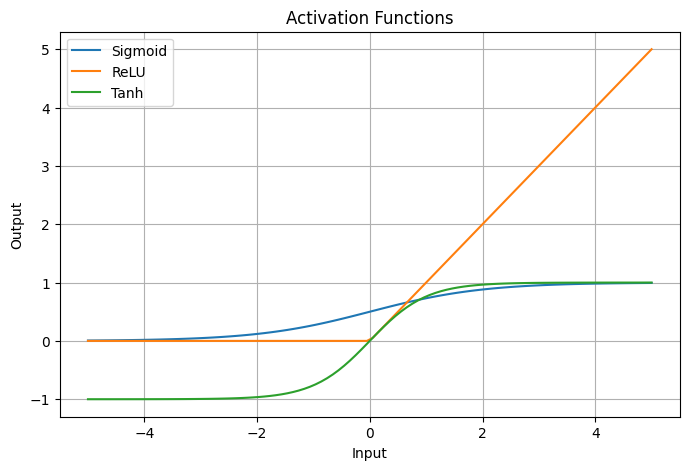

In [5]:
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(8, 5))

plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, tanh(x), label="Tanh")

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Activation Functions")

plt.legend()
plt.grid(True)

plt.show()

## Activation Function Summary

| Function | Common Use |
|---|---|
| Sigmoid | Binary classification |
| ReLU | Hidden layers |
| Tanh | Hidden layers |
| Softmax | Multi-class classification |

ReLU is widely used in hidden layers because it is simple and computationally efficient.

# Part 2 — Backpropagation and Loss Functions

A neural network learns by comparing its prediction with the actual answer.

The difference is measured using a **loss function**.

The network then uses **backpropagation** to calculate how much each weight contributed to the error.

The weights are updated using an optimization algorithm such as Gradient Descent.

### Training Process

Input

↓

Forward Propagation

↓

Prediction

↓

Calculate Loss

↓

Backpropagation

↓

Calculate Gradients

↓

Update Weights

↓

Repeat

## 3. Loss Functions

A loss function measures how wrong the model's prediction is.

Common loss functions include:

### Mean Squared Error (MSE)

Used commonly for regression.

MSE = Average((Actual − Predicted)²)

### Binary Cross-Entropy

Used for binary classification.

### Categorical Cross-Entropy

Used for multi-class classification.

In [6]:
def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


actual = np.array([1, 0, 1])
predicted = np.array([0.9, 0.2, 0.8])

print("MSE:", mse(actual, predicted))

MSE: 0.029999999999999995


## 4. Backpropagation

Backpropagation calculates the gradients of the loss with respect to the network's weights.

These gradients tell us how the weights should change to reduce the loss.

### Gradient Descent

New Weight = Old Weight − Learning Rate × Gradient

The process is repeated over many iterations until the model learns useful weights.

# 5. Building a Neural Network with TensorFlow/Keras

TensorFlow and Keras provide high-level tools for creating and training neural networks.

We will build a classification neural network using Keras.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

iris = load_iris()

X = iris.data
y = iris.target

print("Features:", X.shape)
print("Target:", y.shape)

Features: (150, 4)
Target: (150,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print("Data prepared successfully.")

Data prepared successfully.


## 6. Neural Network Architecture

Our network will contain:

- Input Layer → 4 features
- Hidden Layer → 16 neurons with ReLU
- Hidden Layer → 8 neurons with ReLU
- Output Layer → 3 neurons with Softmax

The output layer contains 3 neurons because the Iris dataset contains 3 classes.

In [11]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Compiling the Model

Before training, we specify:

- Optimizer
- Loss function
- Evaluation metric

We will use:

- Adam optimizer
- Categorical Cross-Entropy loss
- Accuracy

In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3854 - loss: 1.1327 - val_accuracy: 0.5417 - val_loss: 1.0741
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4688 - loss: 1.0900 - val_accuracy: 0.5833 - val_loss: 1.0343
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4896 - loss: 1.0526 - val_accuracy: 0.5833 - val_loss: 1.0007
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 1.0192 - val_accuracy: 0.6250 - val_loss: 0.9713
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5833 - loss: 0.9915 - val_accuracy: 0.6667 - val_loss: 0.9461
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5729 - loss: 0.9631 - val_accuracy: 0.6667 - val_loss: 0.9224
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5938 - loss: 0.9386 - val_accuracy: 0.6667 - val_loss: 0.9002
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6042 - loss: 0.9136 - val_accuracy: 0.6667 - val_loss: 0.8793


In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.40520814061164856
Test Accuracy: 0.7666666507720947


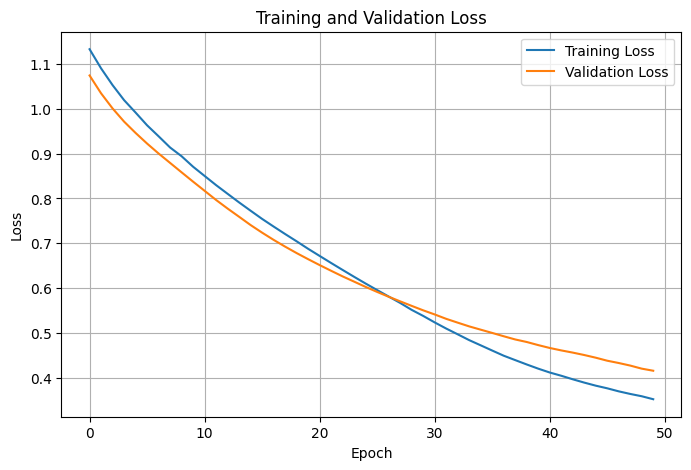

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

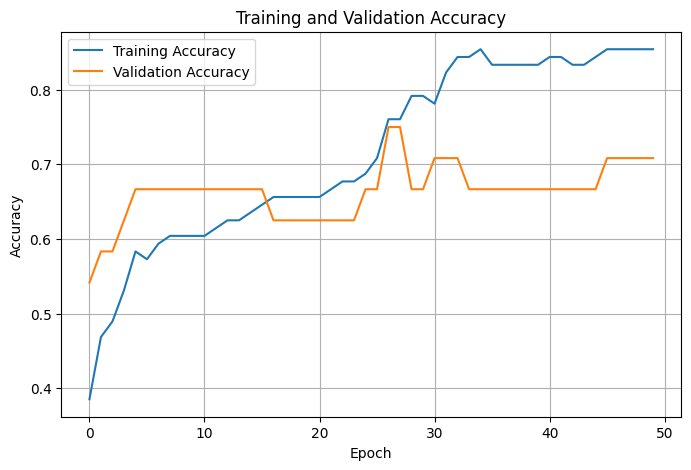

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test, verbose=0)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.30      0.46        10
   virginica       0.59      1.00      0.74        10

    accuracy                           0.77        30
   macro avg       0.86      0.77      0.73        30
weighted avg       0.86      0.77      0.73        30



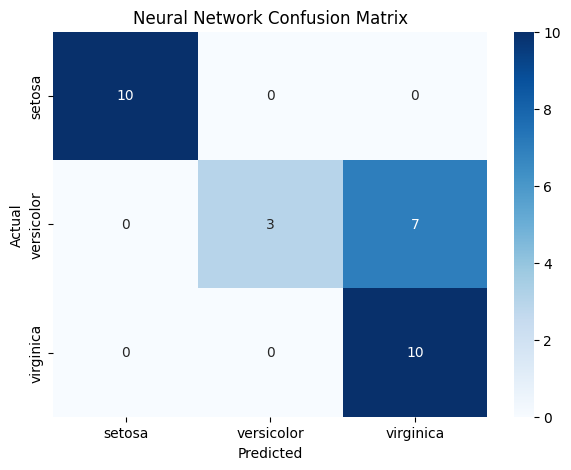

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")

plt.show()

# Neural Networks — Module Complete

## What We Covered

- Neural Networks
- Neurons
- Weights and Bias
- Perceptron
- Activation Functions
- Sigmoid
- ReLU
- Tanh
- Softmax
- Forward Propagation
- Loss Functions
- MSE
- Cross-Entropy
- Backpropagation
- Gradient Descent
- TensorFlow
- Keras
- Dense Layers
- Model Compilation
- Model Training
- Model Evaluation

## Complete Workflow

Dataset
↓
Data Preparation
↓
Feature Scaling
↓
Neural Network Architecture
↓
Forward Propagation
↓
Loss Calculation
↓
Backpropagation
↓
Weight Updates
↓
Training
↓
Evaluation
↓
Predictions

### Key Concept

**Forward Propagation** → Makes the prediction.

**Loss Function** → Measures the error.

**Backpropagation** → Calculates how weights contributed to the error.

**Optimizer** → Updates the weights to reduce the error.